<a href="https://colab.research.google.com/github/SwRI-IDEA-Lab/butterflai/blob/development%2Fjhamilton/weeks/week_02/02_distributions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 02: Statistics of the butterfly wing



## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [3]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [4]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_67066/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_67066/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


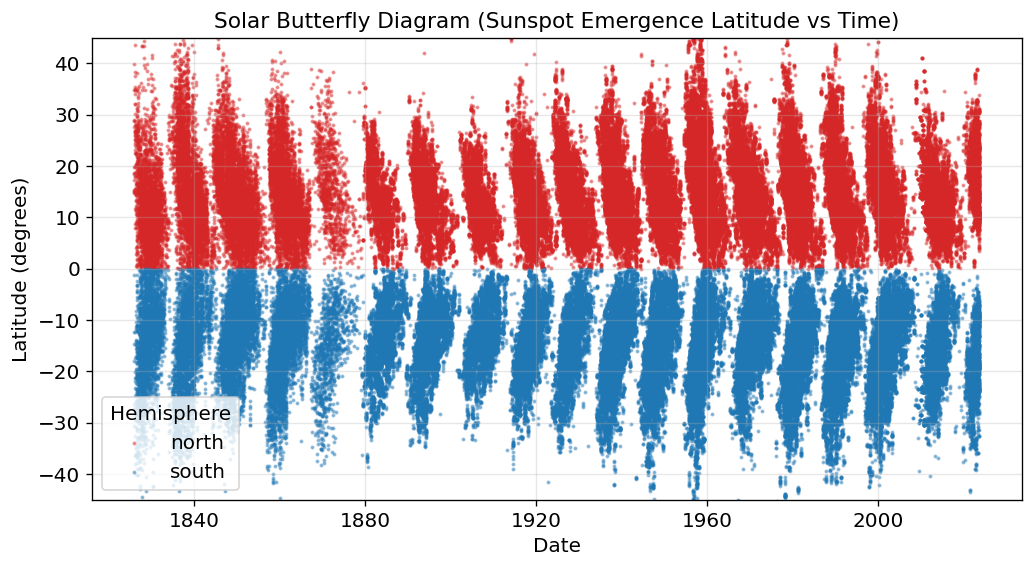

In [5]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


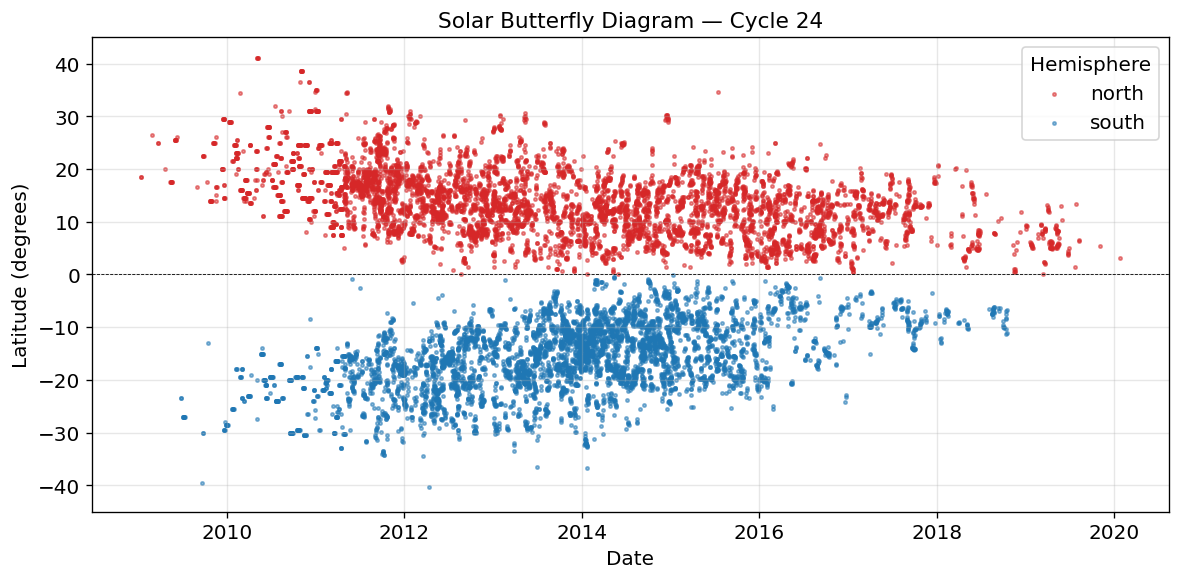

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [6]:
# Task 4: Visualize a single solar cycle
cycle_number = 24  # Change this to explore other cycles

df_cycle = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=4, c=colors[hemi], label=hemi, alpha=0.5)

ax.set_title(f"Solar Butterfly Diagram — Cycle {cycle_number}")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle="--")
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cycle['date'].min().date()} → {df_cycle['date'].max().date()}")
print(f"  N groups: {len(df_cycle):,}")
print(f"  Lat range: [{df_cycle['latitude'].min():.1f}°, {df_cycle['latitude'].max():.1f}°]")


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_67066/2015835256.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", n_cycles)


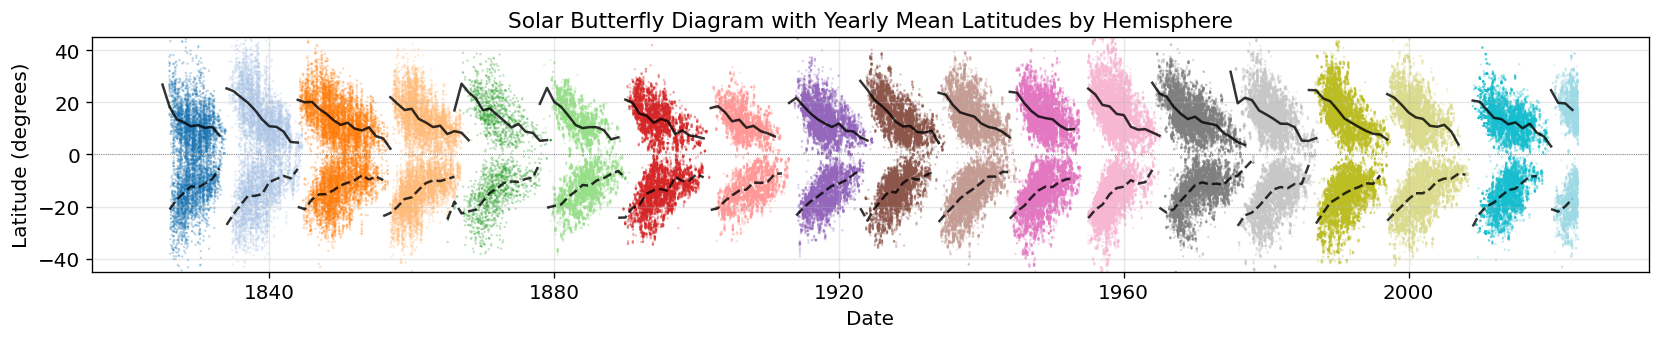

In [7]:
# Task 5: Calculate and plot mean latitudinal paths by cycle

# Generate a colormap for cycles
import matplotlib.cm as cm
import numpy as np

# Filter out rows with missing CYCLE values
cycles = sorted(df["CYCLE"].dropna().unique())
n_cycles = len(cycles)
cmap = cm.get_cmap("tab20", n_cycles)
cycle_colors = {cyc: cmap(i) for i, cyc in enumerate(cycles)}

fig, ax = plt.subplots(figsize=(14, 3))

# Plot butterfly diagram with each cycle in a different color
for cyc in cycles:
    df_cyc = df[df["CYCLE"] == cyc]
    ax.scatter(df_cyc["date"], df_cyc["latitude"], s=2,
               c=[cycle_colors[cyc]], label=f"Cycle {int(cyc)}",
               alpha=0.3, edgecolors="none")

# Calculate and overplot yearly mean latitude for each cycle and hemisphere
df["year"] = df["date"].dt.year

for cyc in cycles:
    df_cyc_all = df[df["CYCLE"] == cyc]

    # Northern hemisphere
    df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
    if len(df_cyc_north) > 0:
        yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_north.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_north.values, color="black",
                linewidth=1.5, linestyle="-", alpha=0.8)

    # Southern hemisphere
    df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
    if len(df_cyc_south) > 0:
        yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
        year_dates = yearly_means_south.index.astype(str)
        year_dates_dt = pd.to_datetime(year_dates + "-01-01")
        ax.plot(year_dates_dt, yearly_means_south.values, color="black",
                linewidth=1.5, linestyle="--", alpha=0.8)

ax.set_title("Solar Butterfly Diagram with Yearly Mean Latitudes by Hemisphere")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()


The cell below does the same, but for a single cycle

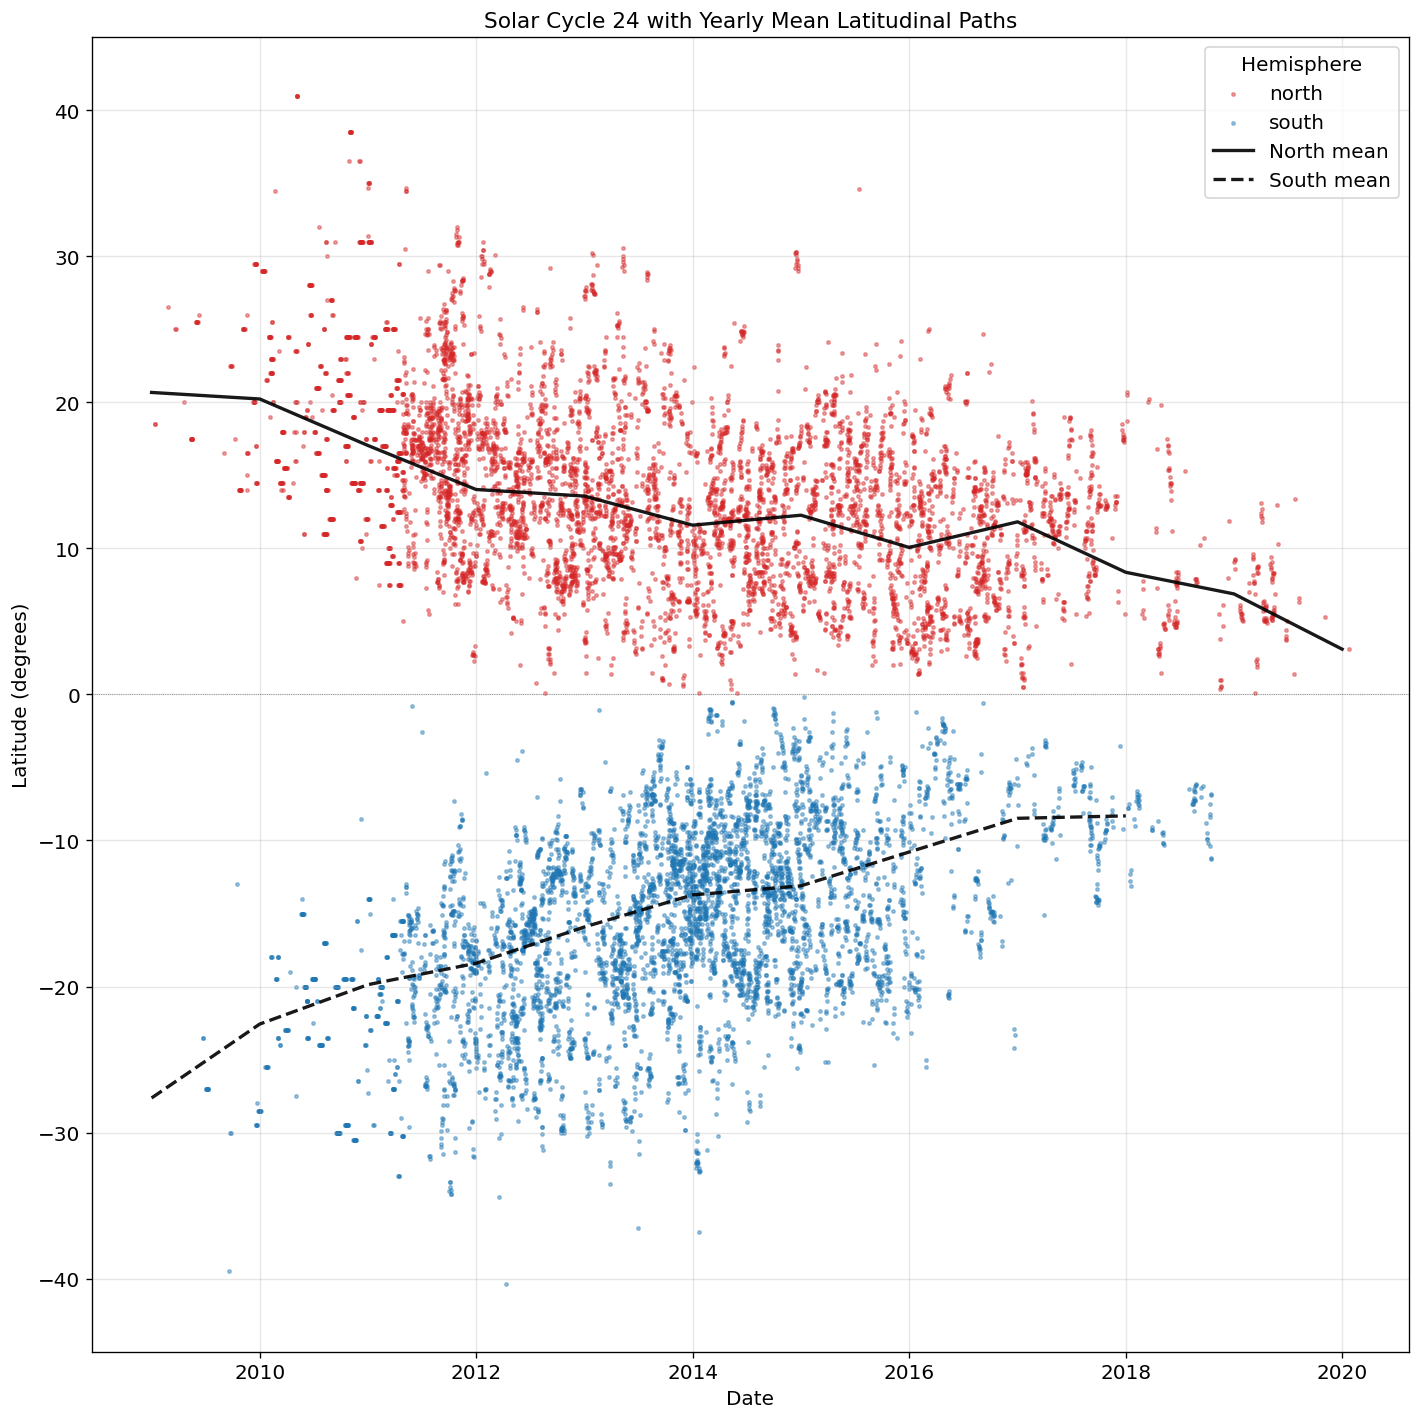

Cycle 24: 2009-01-11 → 2020-01-24
  N groups: 12,154
  Lat range: [-40.4°, 41.0°]


In [8]:
# Bonus: Visualize a single cycle with its mean latitudinal paths
cycle_number = 24  # Change this to explore other cycles

df_cyc_bonus = df[df["CYCLE"] == cycle_number].copy()

fig, ax = plt.subplots(figsize=(12, 12))

# Plot butterfly diagram for this cycle with different colors per hemisphere
for hemi, color in [("north", "tab:red"), ("south", "tab:blue")]:
    df_hemi = df_cyc_bonus[df_cyc_bonus["hemisphere"] == hemi]
    ax.scatter(df_hemi["date"], df_hemi["latitude"], s=4, c=color, label=hemi, alpha=0.4)

# Overplot yearly mean paths for this cycle
df_cyc_all = df[df["CYCLE"] == cycle_number]

# Northern hemisphere mean
df_cyc_north = df_cyc_all[df_cyc_all["hemisphere"] == "north"]
if len(df_cyc_north) > 0:
    yearly_means_north = df_cyc_north.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_north.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_north.values, color="black",
            linewidth=2, linestyle="-", alpha=0.9, label="North mean")

# Southern hemisphere mean
df_cyc_south = df_cyc_all[df_cyc_all["hemisphere"] == "south"]
if len(df_cyc_south) > 0:
    yearly_means_south = df_cyc_south.groupby("year")["latitude"].mean().sort_index()
    year_dates = yearly_means_south.index.astype(str)
    year_dates_dt = pd.to_datetime(year_dates + "-01-01")
    ax.plot(year_dates_dt, yearly_means_south.values, color="black",
            linewidth=2, linestyle="--", alpha=0.9, label="South mean")

ax.set_title(f"Solar Cycle {cycle_number} with Yearly Mean Latitudinal Paths")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere", loc="upper right")
ax.set_ylim(-45, 45)
ax.axhline(0, color="k", linewidth=0.5, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Cycle {cycle_number}: {df_cyc_bonus['date'].min().date()} → {df_cyc_bonus['date'].max().date()}")
print(f"  N groups: {len(df_cyc_bonus):,}")
print(f"  Lat range: [{df_cyc_bonus['latitude'].min():.1f}°, {df_cyc_bonus['latitude'].max():.1f}°]")


## 6) Empirical Distribution for a Single Year

Before we can model the butterfly diagram statistically, we need to understand what the **distribution of emergence latitudes** looks like at a single moment in time.

**Task:**
- Pick a year (e.g. 1960) and a hemisphere (north or south), and filter the data to that year and hemisphere.
- Plot a **histogram** of emergence latitudes (density-normalized so it compares to a PDF).
- Add vertical lines marking the **median**, **Q1**, and **Q3**, and shade the IQR.
- What shape does the distribution have? Is it symmetric? Try switching to the other hemisphere and try different years — does the shape change?


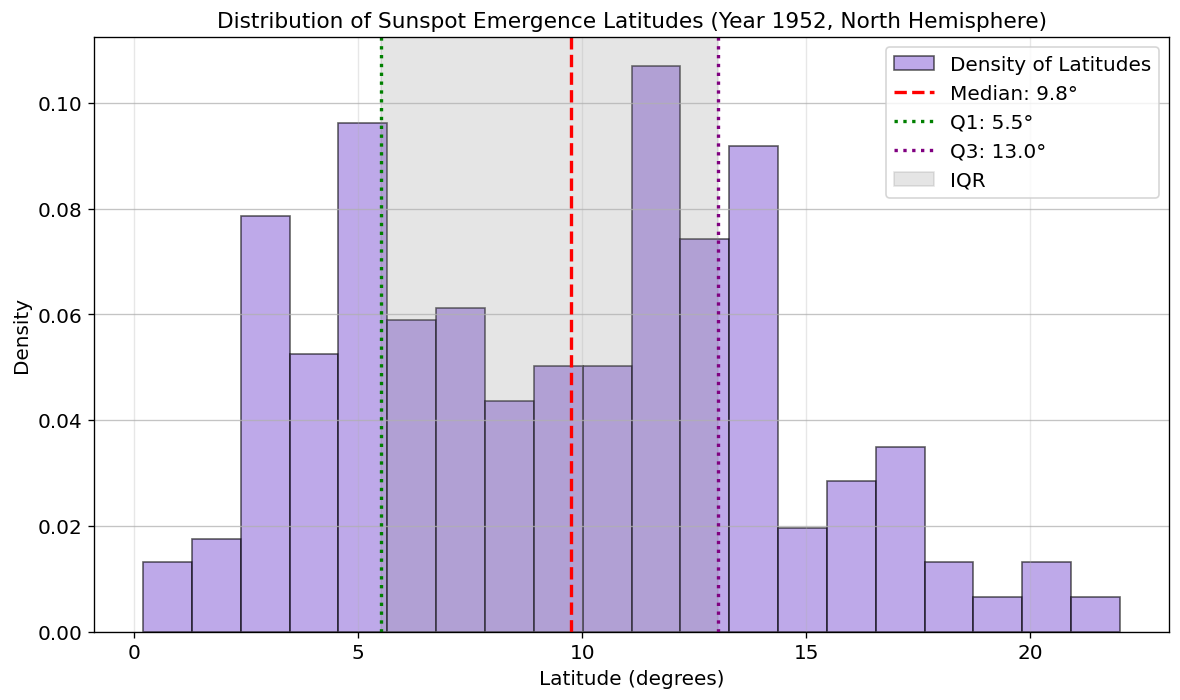

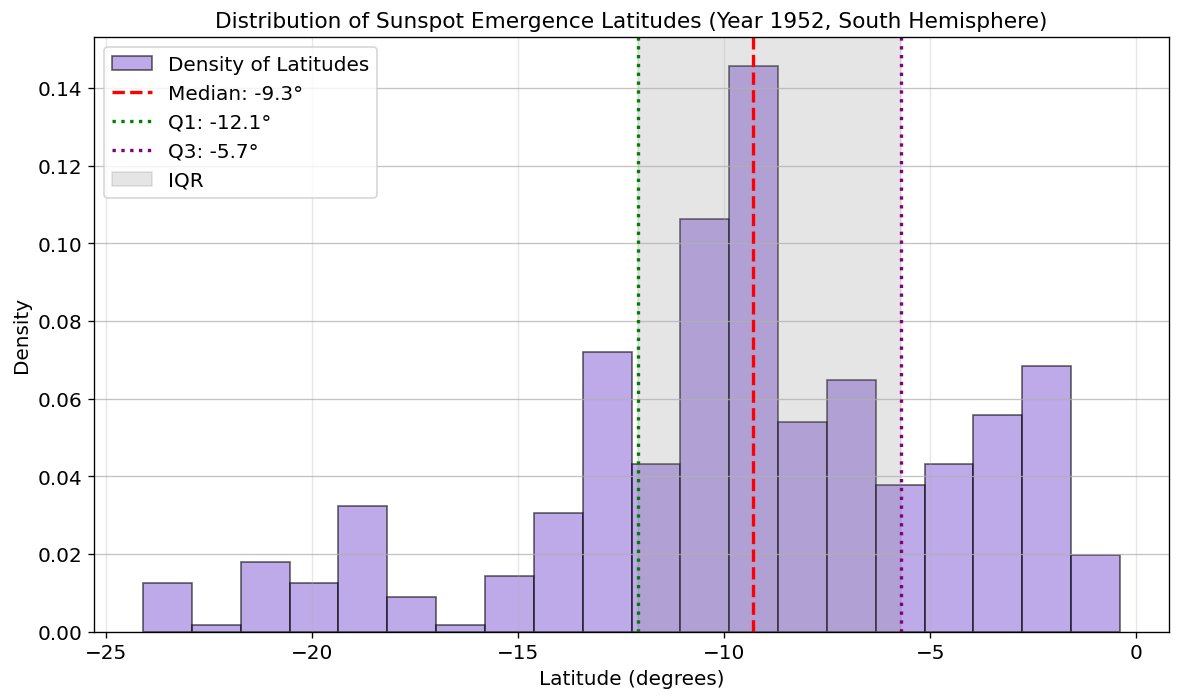

In [9]:
# Put your code for Task 6 here
year = 1952
hemisphere = "north"

df_filtered = df[(df['year'] == year) & (df['hemisphere'] == hemisphere)].copy()

# Calculate median, Q1, and Q3 - This computes the mean latitude and the quantiles
# where Q1 is 0.25 and then 0.75 (like percentages)
median_lat = df_filtered['latitude'].median()
q1_lat = df_filtered['latitude'].quantile(0.25)
q3_lat = df_filtered['latitude'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_filtered['latitude'], bins=20, density=True, alpha=0.6, color='mediumpurple', edgecolor='black', label='Density of Latitudes')

# Add vertical lines for median, Q1, and Q3 - this adds the respective lines
ax.axvline(median_lat, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lat:.1f}°')
ax.axvline(q1_lat, color='green', linestyle=':', linewidth=2, label=f'Q1: {q1_lat:.1f}°')
ax.axvline(q3_lat, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3_lat:.1f}°')

# Shade the IQR - this shades the region between the two quartiles called the interquartile range (IQR)
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='IQR')

#Setting Labels
ax.set_title(f'Distribution of Sunspot Emergence Latitudes (Year {year}, {hemisphere.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

########################################################################################
year = 1952
hemisphere = "south"

df_filtered = df[(df['year'] == year) & (df['hemisphere'] == hemisphere)].copy()

# Calculate median, Q1, and Q3 - This computes the mean latitude and the quantiles
# where Q1 is 0.25 and then 0.75 (like percentages)
median_lat = df_filtered['latitude'].median()
q1_lat = df_filtered['latitude'].quantile(0.25)
q3_lat = df_filtered['latitude'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_filtered['latitude'], bins=20, density=True, alpha=0.6, color='mediumpurple', edgecolor='black', label='Density of Latitudes')

# Add vertical lines for median, Q1, and Q3 - this adds the respective lines
ax.axvline(median_lat, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lat:.1f}°')
ax.axvline(q1_lat, color='green', linestyle=':', linewidth=2, label=f'Q1: {q1_lat:.1f}°')
ax.axvline(q3_lat, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3_lat:.1f}°')

# Shade the IQR - this shades the region between the two quartiles called the interquartile range (IQR)
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='IQR')

#Setting Labels
ax.set_title(f'Distribution of Sunspot Emergence Latitudes (Year {year}, {hemisphere.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

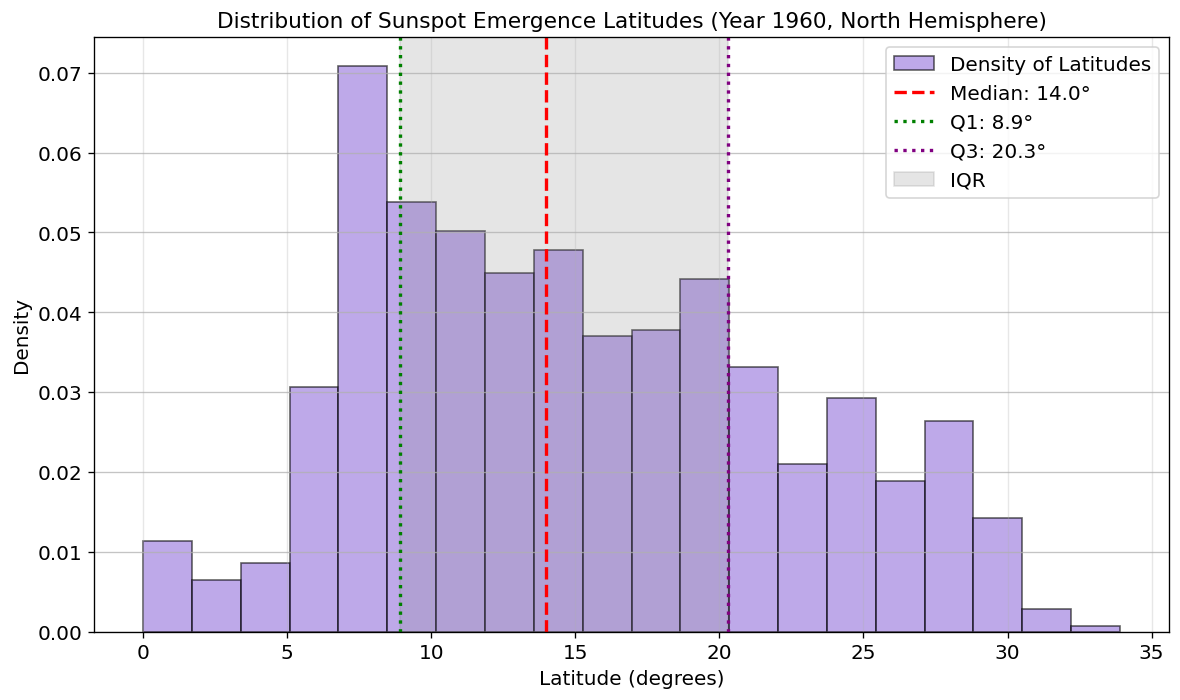

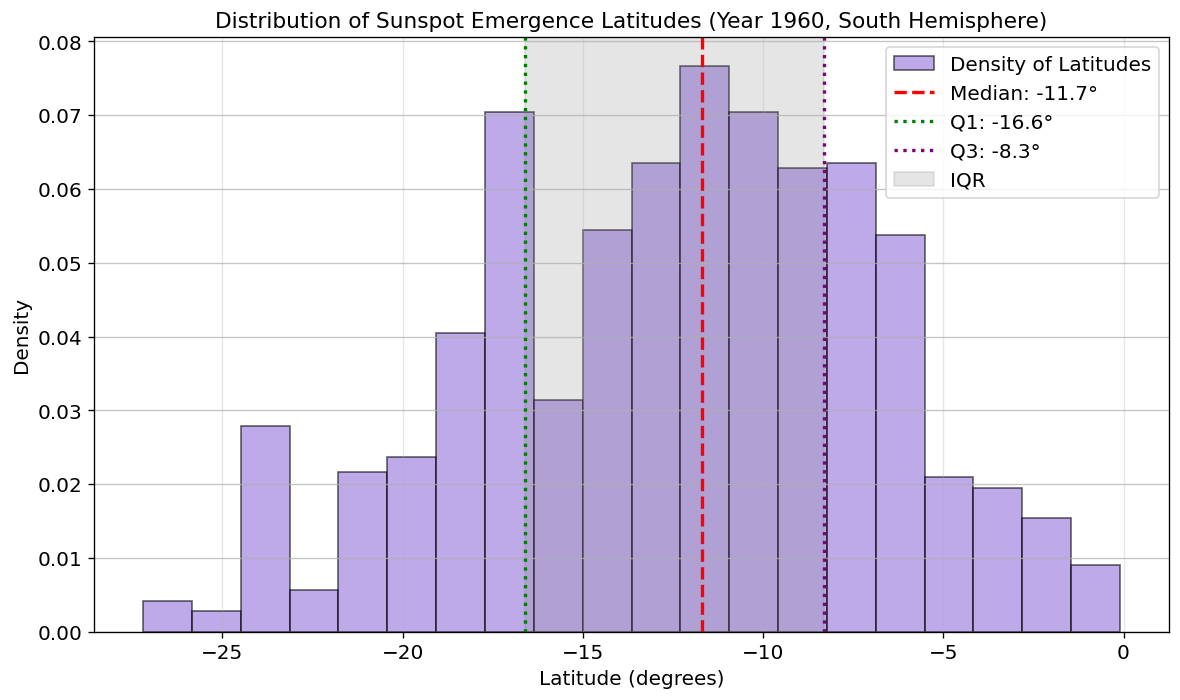

In [10]:
# Put your code for Task 6 here
year = 1960
hemisphere = "north"

df_filtered = df[(df['year'] == year) & (df['hemisphere'] == hemisphere)].copy()

# Calculate median, Q1, and Q3 - This computes the mean latitude and the quantiles
# where Q1 is 0.25 and then 0.75 (like percentages)
median_lat = df_filtered['latitude'].median()
q1_lat = df_filtered['latitude'].quantile(0.25)
q3_lat = df_filtered['latitude'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_filtered['latitude'], bins=20, density=True, alpha=0.6, color='mediumpurple', edgecolor='black', label='Density of Latitudes')

# Add vertical lines for median, Q1, and Q3 - this adds the respective lines
ax.axvline(median_lat, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lat:.1f}°')
ax.axvline(q1_lat, color='green', linestyle=':', linewidth=2, label=f'Q1: {q1_lat:.1f}°')
ax.axvline(q3_lat, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3_lat:.1f}°')

# Shade the IQR - this shades the region between the two quartiles called the interquartile range (IQR)
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='IQR')

#Setting Labels
ax.set_title(f'Distribution of Sunspot Emergence Latitudes (Year {year}, {hemisphere.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

########################################################################################
year = 1960
hemisphere = "south"

df_filtered = df[(df['year'] == year) & (df['hemisphere'] == hemisphere)].copy()

# Calculate median, Q1, and Q3 - This computes the mean latitude and the quantiles
# where Q1 is 0.25 and then 0.75 (like percentages)
median_lat = df_filtered['latitude'].median()
q1_lat = df_filtered['latitude'].quantile(0.25)
q3_lat = df_filtered['latitude'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_filtered['latitude'], bins=20, density=True, alpha=0.6, color='mediumpurple', edgecolor='black', label='Density of Latitudes')

# Add vertical lines for median, Q1, and Q3 - this adds the respective lines
ax.axvline(median_lat, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lat:.1f}°')
ax.axvline(q1_lat, color='green', linestyle=':', linewidth=2, label=f'Q1: {q1_lat:.1f}°')
ax.axvline(q3_lat, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3_lat:.1f}°')

# Shade the IQR - this shades the region between the two quartiles called the interquartile range (IQR)
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='IQR')

#Setting Labels
ax.set_title(f'Distribution of Sunspot Emergence Latitudes (Year {year}, {hemisphere.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

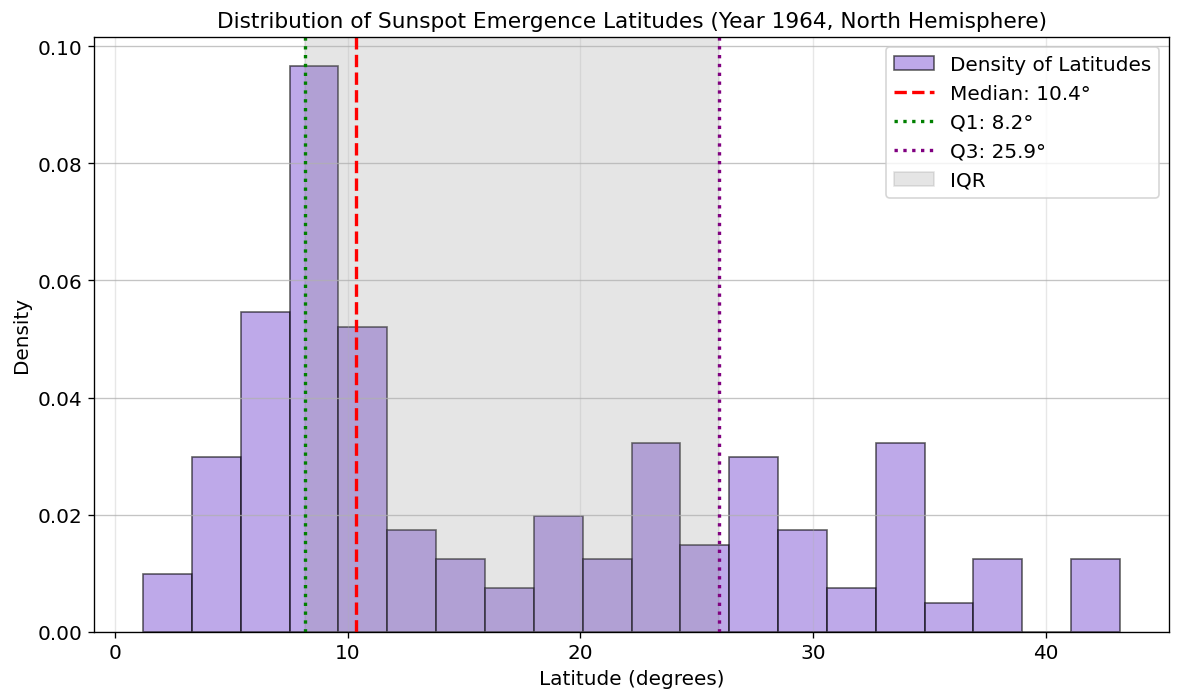

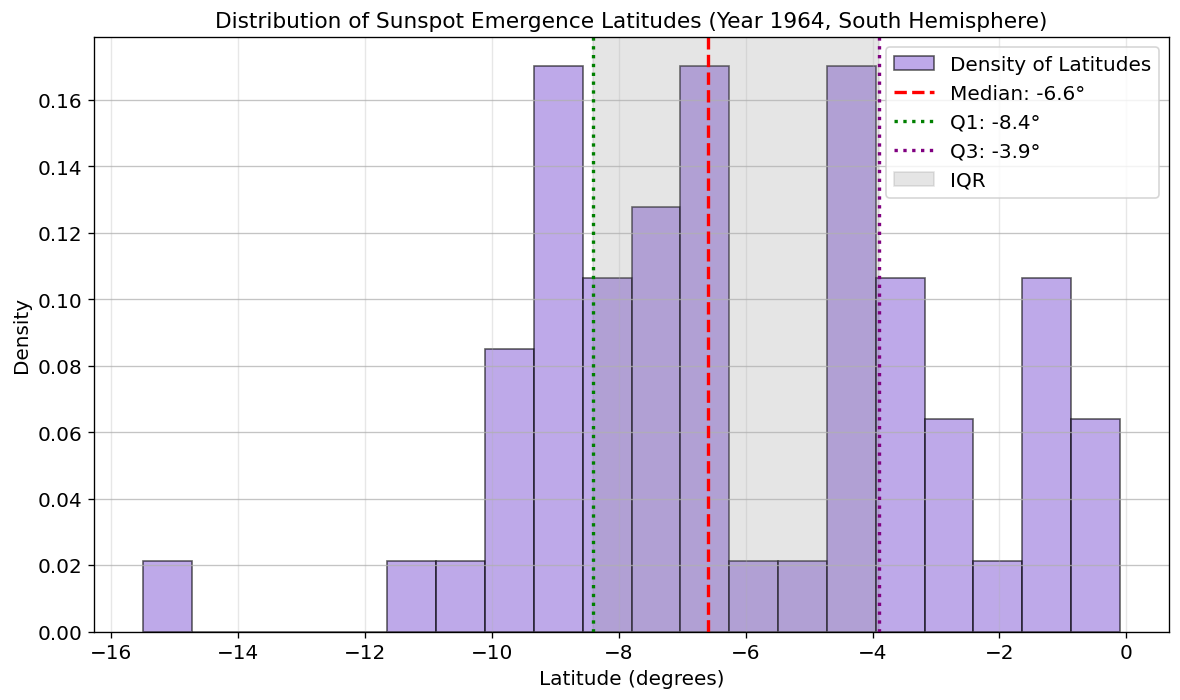

In [11]:
year = 1964
hemisphere = "north"

df_filtered = df[(df['year'] == year) & (df['hemisphere'] == hemisphere)].copy()

# Calculate median, Q1, and Q3 - This computes the mean latitude and the quantiles
# where Q1 is 0.25 and then 0.75 (like percentages)
median_lat = df_filtered['latitude'].median()
q1_lat = df_filtered['latitude'].quantile(0.25)
q3_lat = df_filtered['latitude'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_filtered['latitude'], bins=20, density=True, alpha=0.6, color='mediumpurple', edgecolor='black', label='Density of Latitudes')

# Add vertical lines for median, Q1, and Q3 - this adds the respective lines
ax.axvline(median_lat, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lat:.1f}°')
ax.axvline(q1_lat, color='green', linestyle=':', linewidth=2, label=f'Q1: {q1_lat:.1f}°')
ax.axvline(q3_lat, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3_lat:.1f}°')

# Shade the IQR - this shades the region between the two quartiles called the interquartile range (IQR)
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='IQR')

#Setting Labels
ax.set_title(f'Distribution of Sunspot Emergence Latitudes (Year {year}, {hemisphere.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

########################################################################################
year = 1964
hemisphere = "south"

df_filtered = df[(df['year'] == year) & (df['hemisphere'] == hemisphere)].copy()

# Calculate median, Q1, and Q3 - This computes the mean latitude and the quantiles
# where Q1 is 0.25 and then 0.75 (like percentages)
median_lat = df_filtered['latitude'].median()
q1_lat = df_filtered['latitude'].quantile(0.25)
q3_lat = df_filtered['latitude'].quantile(0.75)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_filtered['latitude'], bins=20, density=True, alpha=0.6, color='mediumpurple', edgecolor='black', label='Density of Latitudes')

# Add vertical lines for median, Q1, and Q3 - this adds the respective lines
ax.axvline(median_lat, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lat:.1f}°')
ax.axvline(q1_lat, color='green', linestyle=':', linewidth=2, label=f'Q1: {q1_lat:.1f}°')
ax.axvline(q3_lat, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3_lat:.1f}°')

# Shade the IQR - this shades the region between the two quartiles called the interquartile range (IQR)
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='IQR')

#Setting Labels
ax.set_title(f'Distribution of Sunspot Emergence Latitudes (Year {year}, {hemisphere.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

Looking at a few different years (1956, 1960, 1964) specifically to showcase variation through a solar cycle (though not a full cycle), I see the mean value of the latitudes drift toward the equator. Move of the data has a decent Gaussian distribution except for towards the end of the cycle. I believe there is an overlap that occurs as the next cycle is beginning the other cycle is ending, which influences the distribution...maybe.

## 7) Fitting an Analytical Distribution

An empirical histogram is useful but noisy. A fitted **analytical distribution** gives us a smooth, compact description of the data — and forces us to ask whether our chosen family of curves actually matches reality.

**Task:**
- Using the same year and hemisphere as Task 6, fit a **Normal (Gaussian) distribution** to the latitude data and overlay the fitted PDF on the histogram.
- Does it fit well? Where does it agree with the data and where does it fail?
- The Gaussian has two parameters (μ, σ). What do they represent physically for sunspot emergence?

**Hint:** `scipy.stats.norm.fit(data)` returns `(mu, sigma)`. Use `norm.pdf(x, mu, sigma)` to evaluate the PDF on a grid of x values.


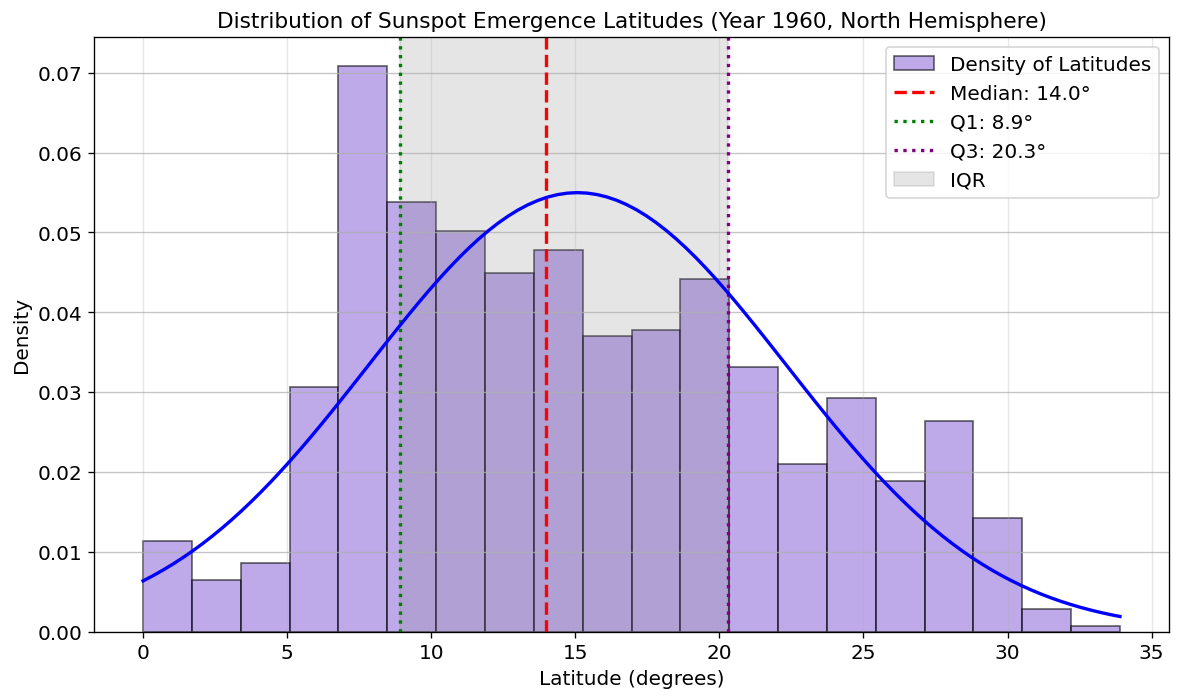

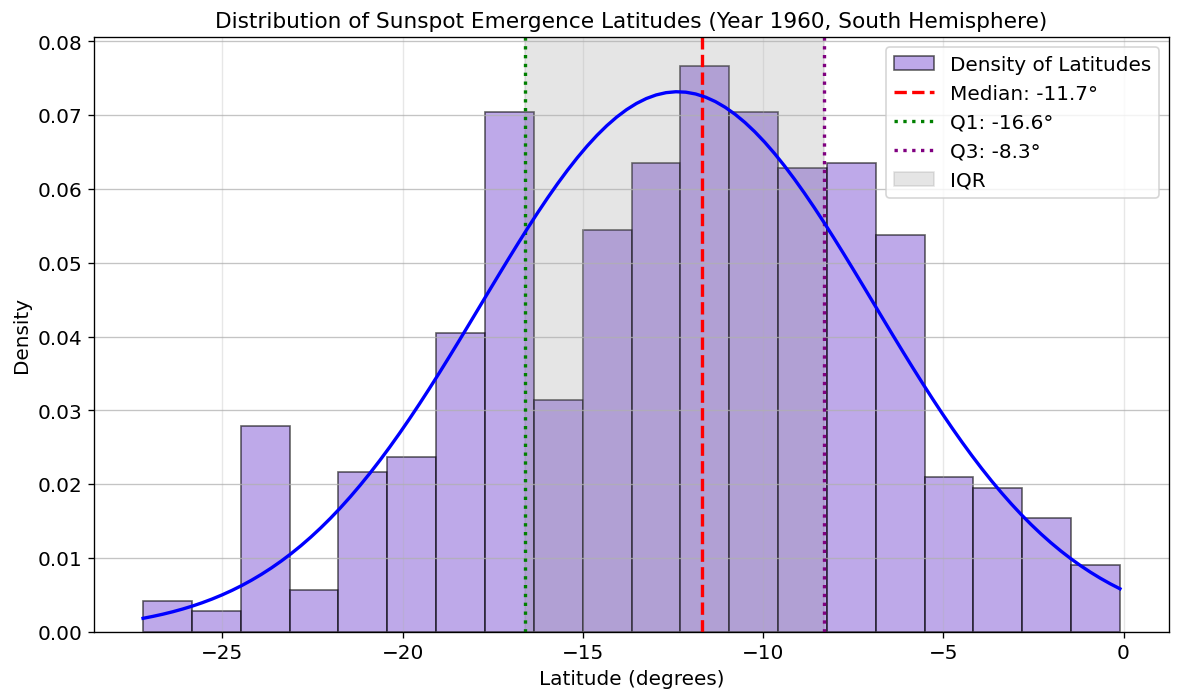

In [15]:
# Put your code for Task 7 here
from scipy.stats import norm
year = 1960
hemisphere = "north"

df_filtered = df[(df['year'] == year) & (df['hemisphere'] == hemisphere)].copy()

# Calculate median, Q1, and Q3 - This computes the mean latitude and the quantiles
# where Q1 is 0.25 and then 0.75 (like percentages)
median_lat = df_filtered['latitude'].median()
q1_lat = df_filtered['latitude'].quantile(0.25)
q3_lat = df_filtered['latitude'].quantile(0.75)

#Fitting a normal Gaussian distribution to the latitude data
mu, sigma = norm.fit(df_filtered['latitude'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_filtered['latitude'], bins=20, density=True, alpha=0.6, color='mediumpurple', edgecolor='black', label='Density of Latitudes')

# Add vertical lines for median, Q1, and Q3 - this adds the respective lines
ax.axvline(median_lat, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lat:.1f}°')
ax.axvline(q1_lat, color='green', linestyle=':', linewidth=2, label=f'Q1: {q1_lat:.1f}°')
ax.axvline(q3_lat, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3_lat:.1f}°')

# Shade the IQR - this shades the region between the two quartiles called the interquartile range (IQR)
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='IQR')

#Overlaying the fitted Gaussian PDF over the histogram
x = np.linspace(df_filtered['latitude'].min(), df_filtered['latitude'].max(), 100)
ax.plot(x, norm.pdf(x, mu, sigma), color='blue', linewidth=2)

#Setting Labels
ax.set_title(f'Distribution of Sunspot Emergence Latitudes (Year {year}, {hemisphere.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

########################################################################################
year = 1960
hemisphere = "south"

df_filtered = df[(df['year'] == year) & (df['hemisphere'] == hemisphere)].copy()

# Calculate median, Q1, and Q3 - This computes the mean latitude and the quantiles
# where Q1 is 0.25 and then 0.75 (like percentages)
median_lat = df_filtered['latitude'].median()
q1_lat = df_filtered['latitude'].quantile(0.25)
q3_lat = df_filtered['latitude'].quantile(0.75)

#Fitting a normal Gaussian distribution to the latitude data
mu, sigma = norm.fit(df_filtered['latitude'])

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df_filtered['latitude'], bins=20, density=True, alpha=0.6, color='mediumpurple', edgecolor='black', label='Density of Latitudes')

# Add vertical lines for median, Q1, and Q3 - this adds the respective lines
ax.axvline(median_lat, color='red', linestyle='--', linewidth=2, label=f'Median: {median_lat:.1f}°')
ax.axvline(q1_lat, color='green', linestyle=':', linewidth=2, label=f'Q1: {q1_lat:.1f}°')
ax.axvline(q3_lat, color='purple', linestyle=':', linewidth=2, label=f'Q3: {q3_lat:.1f}°')

# Shade the IQR - this shades the region between the two quartiles called the interquartile range (IQR)
ax.axvspan(q1_lat, q3_lat, color='gray', alpha=0.2, label='IQR')

#Overlaying the fitted Gaussian PDF over the histogram
x = np.linspace(df_filtered['latitude'].min(), df_filtered['latitude'].max(), 100)
ax.plot(x, norm.pdf(x, mu, sigma), color='blue', linewidth=2)

#Setting Labels
ax.set_title(f'Distribution of Sunspot Emergence Latitudes (Year {year}, {hemisphere.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()

It seems here the best fit Gaussian falls with the southern hemisphere. The northern hemisphere has a large outlier bin around 7 that is shifting the mean value towards the equator. There is an outlier in the southern hemisphere towards the higher latitudes, but it is balanced out pretty well with the volume of sunspots at lower latitudes. For the μ and σ for the Gaussian distribution: μ represents the mean of the data displayed. If the mean changes, the entire curve will shift. The σ represents the standard deviation of the data. This will show you how sharp or round the peak of the curve will be.

## 8) Distribution Evolution Through a Solar Cycle

A single year's distribution is a snapshot. Over the course of a solar cycle, the distribution **drifts toward the equator** as the cycle ages — this is **Spörer's Law**, one of the most important empirical regularities in solar physics.

**Task:**
- Pick a solar cycle (e.g. cycle 24) and a hemisphere, and filter the data to both.
- For each year in that cycle, compute a **KDE (kernel density estimate)** of emergence latitudes.
- Plot all the KDEs overlaid, colored by year so the time progression is clear.
- Do you see the distributions shifting toward the equator as the cycle progresses? Does the width of the distribution change too?

**Hint:** `scipy.stats.gaussian_kde` fits a smooth density to an array of values. The `bw_method` parameter controls smoothing — try values between 0.2 and 0.5.


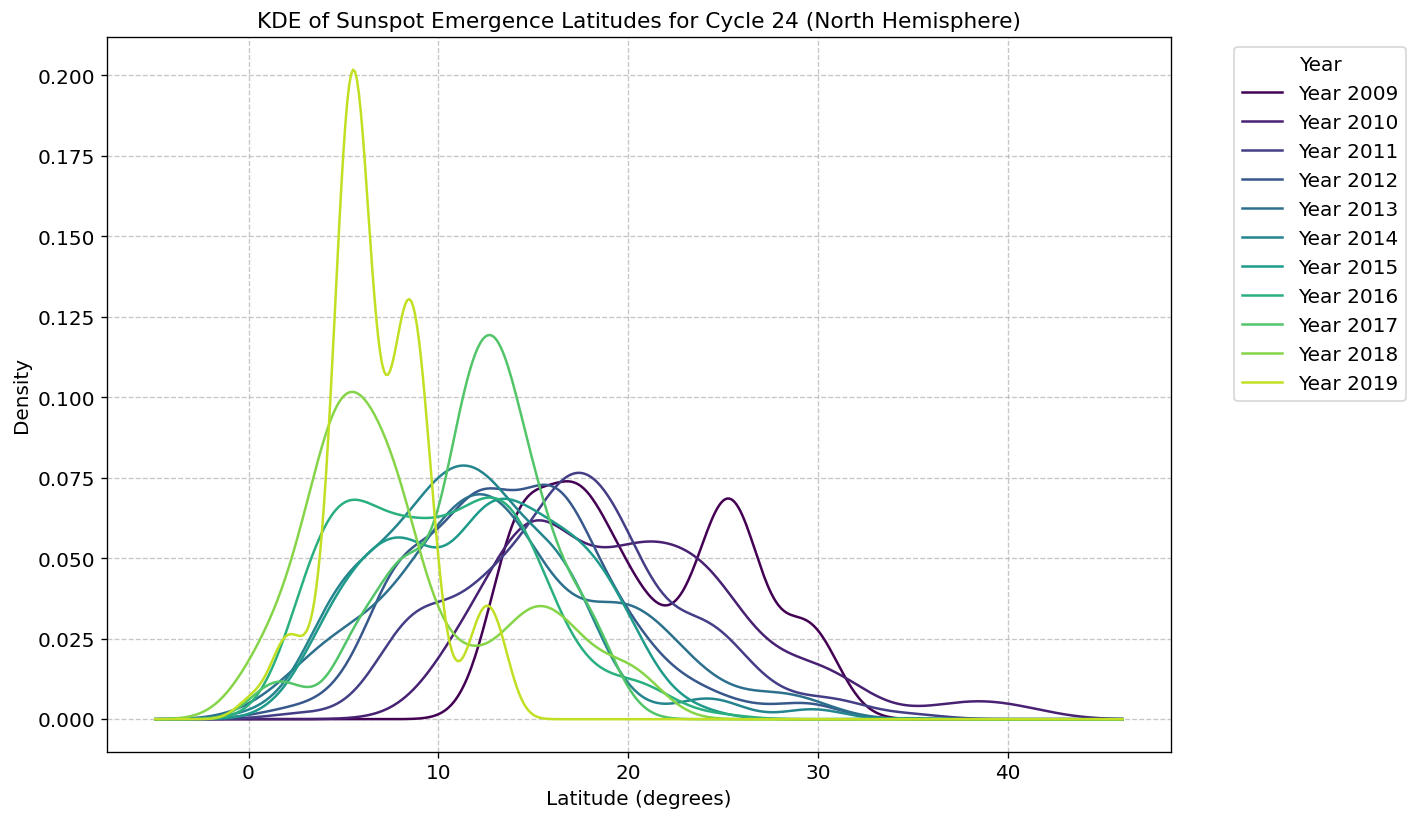

In [12]:
# Put your code for Task 8 here
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

cycle_number = 24
hemisphere = 'north'

df_cycle_hemi = df[(df['CYCLE'] == cycle_number) & (df['hemisphere'] == hemisphere)].copy()

# Get unique years in the cycle for coloring
years = sorted(df_cycle_hemi['year'].unique())
n_years = len(years)
colors = plt.cm.viridis(np.linspace(0, 1, n_years))

fig, ax = plt.subplots(figsize=(12, 7))

# Get a consistent x-range for all KDEs
min_lat = df_cycle_hemi['latitude'].min() - 5
max_lat = df_cycle_hemi['latitude'].max() + 5
x = np.linspace(min_lat, max_lat, 500)

# Compute and plot the KDE for each year
for i, year in enumerate(years):
    df_year = df_cycle_hemi[df_cycle_hemi['year'] == year]

    if len(df_year) > 1: # Need at least 2 points to compute KDE
        kde = stats.gaussian_kde(df_year['latitude'], bw_method=0.3)
        ax.plot(x, kde(x), color=colors[i], label=f'Year {year}')

ax.set_title(f'KDE of Sunspot Emergence Latitudes for Cycle {cycle_number} ({hemisphere.capitalize()} Hemisphere)')
ax.set_xlabel('Latitude (degrees)')
ax.set_ylabel('Density')
ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Here the μ shifts towards 0 (the equator) as the years progress through the cycle. The are The early part of the cycle seems to carry more of a bimodal shape to the distribution. As we progress towards the middle of the cycle (the peak time) the distribution seems to settle into a more original Guassian distribution. As we move towards the end of the cycle, the sigma does shrink as well, but you can note a bump in the tail. The bumps or bimodal like profiles seems to coinside with the beginning and end of the cycle. Maybe due to the start/end of the previous and next cycle.